# 日経平均株価 15分足

In [1]:
import sys

path_up = ".."
if not path_up in sys.path:
    sys.path.append(path_up)

In [2]:
import datetime

import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import mplfinance as mpf
import numpy as np
import pandas as pd
import yfinance as yf

from funcs.commons import get_name_15min_chart, get_name_15min_chart_usd

In [3]:
code = "N225"
symbol = f"^{code}"
yticker = yf.Ticker(symbol)
df = yticker.history(period="1d", interval="15m")
df

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Datetime,,,,,,,
2026-04-23 09:00:00+09:00,59758.640625,60013.980469,59388.378906,59388.378906,0,0.0,0.0
2026-04-23 09:15:00+09:00,59371.289062,59918.468750,59169.898438,59894.218750,0,0.0,0.0
2026-04-23 09:30:00+09:00,59884.738281,59945.691406,59743.148438,59904.839844,0,0.0,0.0
2026-04-23 09:45:00+09:00,59907.218750,59990.480469,59848.140625,59980.539062,0,0.0,0.0
2026-04-23 10:00:00+09:00,59985.320312,59998.441406,59650.160156,59676.078125,0,0.0,0.0
2026-04-23 10:15:00+09:00,59678.859375,59712.718750,59382.589844,59410.121094,0,0.0,0.0
2026-04-23 10:30:00+09:00,59418.261719,59507.441406,59352.769531,59431.761719,0,0.0,0.0
2026-04-23 10:45:00+09:00,59429.488281,59429.488281,59180.621094,59181.761719,0,0.0,0.0
2026-04-23 11:00:00+09:00,59187.890625,59193.878906,58961.929688,58961.929688,0,0.0,0.0


In [4]:
dt_start = df.index[0]
dt_end = pd.to_datetime(
    f"{dt_start.year:04d}-{dt_start.month:02d}-{dt_start.day:02d} 15:30:00+09:00"
).tz_convert("Asia/Tokyo")
dt_start, dt_end

(Timestamp('2026-04-23 09:00:00+0900', tz='Asia/Tokyo'),
 Timestamp('2026-04-23 15:30:00+0900', tz='Asia/Tokyo'))

In [5]:
# 過去一週間のデータを取得
td = datetime.timedelta(days=7)
dt_first = df.index[0]
dt_prev = dt_first - td
df_last = yticker.history(interval="1d", start=str(dt_prev.date()))
print(df_last["Close"])
n = len(df_last)
lastclose = df_last[n - 2 : n - 1]["Close"].iloc[0]
# lastclose = 56308.42  # 4/8 終値
# 確認のため出力
df_last[n - 2 : n - 1]["Close"]

Date
2026-04-16 00:00:00+09:00    59518.339844
2026-04-17 00:00:00+09:00    58475.898438
2026-04-20 00:00:00+09:00    58824.890625
2026-04-21 00:00:00+09:00    59349.171875
2026-04-22 00:00:00+09:00    59585.859375
2026-04-23 00:00:00+09:00    58951.000000
Name: Close, dtype: float64


Date
2026-04-22 00:00:00+09:00    59585.859375
Name: Close, dtype: float64

In [6]:
delta_open = df.head(1)["Open"].iloc[0] - lastclose
print(f"{delta_open:+.2f}")

+172.78


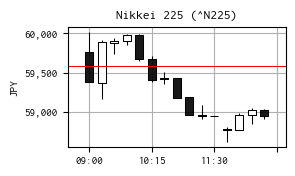

In [7]:
FONT_PATH = "../fonts/RictyDiminished-Regular.ttf"
fm.fontManager.addfont(FONT_PATH)

# FontPropertiesオブジェクト生成（名前の取得のため）
font_prop = fm.FontProperties(fname=FONT_PATH)
font_prop.get_name()

plt.rcParams["font.family"] = font_prop.get_name()
plt.rcParams["font.size"] = 8

fig, ax = plt.subplots(figsize=(3, 1.8))

ax.axhline(y=lastclose, color="red", linewidth=0.75)
mpf.plot(
    df,
    type="candle",
    style="default",
    datetime_format="%H:%M",
    xrotation=0,
    update_width_config=dict(candle_linewidth=0.75),
    ax=ax,
)
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.0f}"))
ax.set_ylabel("JPY")
ax.grid()

if "shortName" in yticker.info:
    ax.set_title(f"{yticker.info['shortName']} ({symbol})")
elif "longName" in yticker.info:
    ax.set_title(f"{yticker.info['longName']} ({symbol})")
else:
    ax.set_title(f"{symbol}")

plt.tight_layout()
plt.savefig(get_name_15min_chart(code, dt_first))
plt.show()

In [8]:
code2 = "USDJPY=X"
symbol2 = code2
ticker2 = yf.Ticker(symbol2)

In [9]:
# 15分足で過去 2 日分のデータを取得
df_exchange = ticker2.history(period="2d", interval="15m")
df_exchange.index = df_exchange.index.tz_convert("Asia/Tokyo")
df_exchange

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Datetime,,,,,,,
2026-04-22 08:00:00+09:00,159.412003,159.457001,159.389008,159.440994,0,0.0,0.0
2026-04-22 08:15:00+09:00,159.432999,159.455994,159.382004,159.404999,0,0.0,0.0
2026-04-22 08:30:00+09:00,159.404999,159.436005,159.397003,159.416000,0,0.0,0.0
2026-04-22 08:45:00+09:00,159.417007,159.429001,159.352005,159.375000,0,0.0,0.0
2026-04-22 09:00:00+09:00,159.376999,159.380997,159.238998,159.287994,0,0.0,0.0
...,...,...,...,...,...,...,...
2026-04-23 12:30:00+09:00,159.526993,159.537994,159.488998,159.518005,0,0.0,0.0
2026-04-23 12:45:00+09:00,159.518005,159.546005,159.488998,159.537994,0,0.0,0.0
2026-04-23 13:00:00+09:00,159.542007,159.584000,159.526993,159.557007,0,0.0,0.0


In [10]:
ser_rate = df_exchange.loc[df.index, "Close"]
ser_rate
df2 = pd.DataFrame()
df2["Open"] = df["Open"] / ser_rate
df2["High"] = df["High"] / ser_rate
df2["Low"] = df["Low"] / ser_rate
df2["Close"] = df["Close"] / ser_rate
df2

,Open,High,Low,Close
Datetime,,,,
2026-04-23 09:00:00+09:00,374.453370,376.053354,372.133275,372.133275
2026-04-23 09:15:00+09:00,372.455629,375.888267,371.192239,375.736139
2026-04-23 09:30:00+09:00,375.726154,376.108583,374.837797,375.852274
2026-04-23 09:45:00+09:00,376.008742,376.531336,375.637937,376.468938
2026-04-23 10:00:00+09:00,376.413906,376.496242,374.310743,374.473380
2026-04-23 10:15:00+09:00,374.413289,374.625716,372.554553,372.727278
2026-04-23 10:30:00+09:00,372.878942,373.438589,372.467946,372.963661
2026-04-23 10:45:00+09:00,372.893263,372.893263,371.331734,371.338891
2026-04-23 11:00:00+09:00,371.144456,371.182006,369.727542,369.727542


In [11]:
dt = df_exchange.head(1).index[0]
dt_last_close = pd.to_datetime(f"{str(dt.date())} 15:15:00+09:00")
print(dt_last_close)
last_close_usd = df_exchange.loc[dt_last_close, "Close"]
last_close_usd

2026-04-22 15:15:00+09:00


np.float64(159.18099975585938)

前日終値（ドル換算） 374.32771163888026


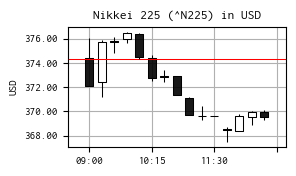

In [12]:
FONT_PATH = "../fonts/RictyDiminished-Regular.ttf"
fm.fontManager.addfont(FONT_PATH)

# FontPropertiesオブジェクト生成（名前の取得のため）
font_prop = fm.FontProperties(fname=FONT_PATH)
font_prop.get_name()

plt.rcParams["font.family"] = font_prop.get_name()
plt.rcParams["font.size"] = 8

fig, ax = plt.subplots(figsize=(3, 1.8))

ax.axhline(y=lastclose / last_close_usd, color="red", linewidth=0.75)
print("前日終値（ドル換算）", lastclose / last_close_usd)
mpf.plot(
    df2,
    type="candle",
    style="default",
    datetime_format="%H:%M",
    xrotation=0,
    update_width_config=dict(candle_linewidth=0.75),
    ax=ax,
)
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.2f}"))
ax.set_ylabel("USD")
ax.grid()

if "shortName" in yticker.info:
    ax.set_title(f"{yticker.info['shortName']} ({symbol}) in USD")
elif "longName" in yticker.info:
    ax.set_title(f"{yticker.info['longName']} ({symbol}) in USD")
else:
    ax.set_title(f"{symbol}")

plt.tight_layout()
plt.savefig(get_name_15min_chart_usd(code, dt_first))
plt.show()